# ARTI404 — Image Processing
## Lab 4 — Intensity Transformations and Filtering-Spatial Domain

**Session 4 · Intensity Transformations and Filtering-Spatial Domain**
Thresholding and histogram-based intensity transformations (contrast stretching, histogram equalization, and histogram matching) using OpenCV, scikit-image, NumPy, and Matplotlib.

| | |
|---|---|
| **Duration** | 100 minutes |
| **Outcome** | Write a program that implements fundamental image processing algorithms |
| **Tools** | Python 3, Anaconda (Jupyter / Spyder); Libraries: OpenCV, NumPy, Pillow, scikit-image, Matplotlib |

---

### How to work through the notebook

* The lab has two tasks — **Task #1: Thresholding** and **Task #2: Histogram Processing** — followed by the **Assessment**.
* Run the cells **in order**, top to bottom.
* Task #1 needs an image file that is **not included** in this notebook — see the note right before it for exactly where to place it.
* Task #2 and the Assessment use `skimage.data.moon()` / `rocket()` / `chelsea()`, scikit-image's built-in sample images, so those cells need no external files and were run for real while preparing this notebook.

---

### By the end of this lab you should be able to

1. Apply fixed-threshold binary thresholding and see how the threshold value changes the result.
2. Stretch an image's contrast to a chosen percentile range and read a pixel-intensity histogram.
3. Equalize an image's histogram to spread out its intensity distribution.
4. Match one image's histogram to a reference image's.

---
## Setup

Run this cell first. It imports every library used in this lab and confirms they are installed.

In [1]:
# If a library below is missing, install it first (uncomment as needed):
#%pip install opencv-python numpy matplotlib scikit-image pillow

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage
from skimage import data, exposure

print("OpenCV      :", cv2.__version__)
print("NumPy       :", np.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("scikit-image:", skimage.__version__)

print("\nSetup OK")

OpenCV      : 5.0.0
NumPy       : 2.5.3
Matplotlib  : 3.11.2
scikit-image: 0.26.0

Setup OK


---
## Task #1 — Thresholding

Thresholding converts a grayscale image into a binary image: every pixel at or above the threshold becomes white (the foreground), and every pixel below it becomes black (the background). It is a simple way to separate objects from the background when there is good contrast between them.

> **Before running the cell below:** create a folder named `images` **one level above** this notebook's folder (i.e. `../images/`), and place the lab's picture inside it as `images/Parrot.png`. No image was provided with this lab, so **this cell has not been run against a real picture** — ask your instructor for `Parrot.png`, or use your own image and change the path below.

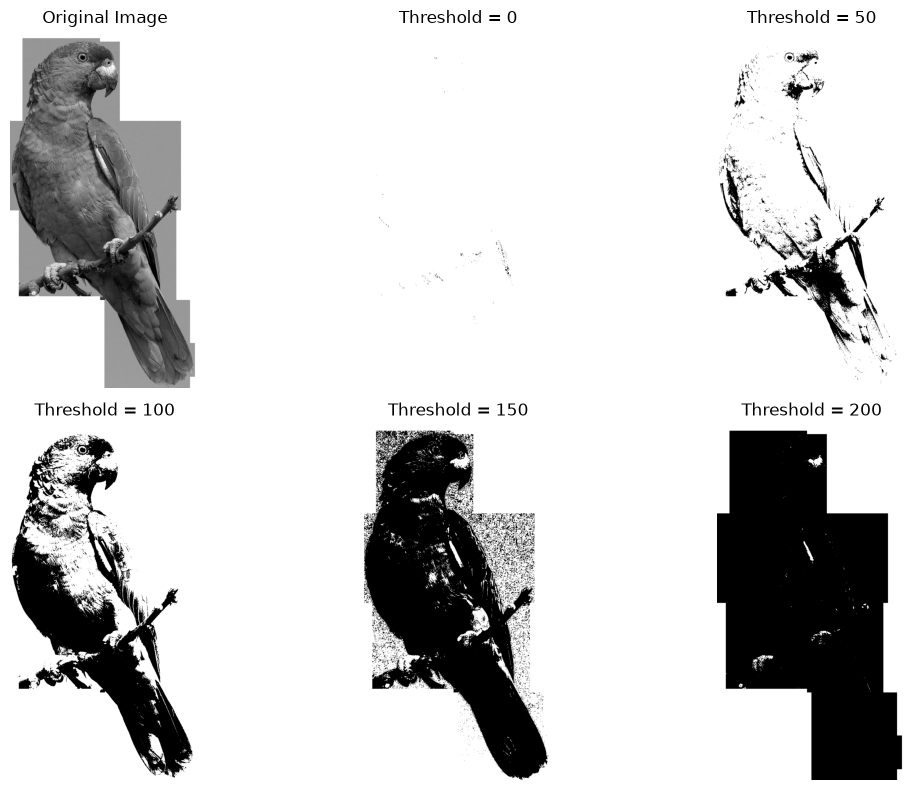

In [2]:
# Load the image in grayscale
img = cv2.imread('../images/Parrot.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: unable to load image at ../images/Parrot.png")

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with each threshold value and collect the results
thresholded_images = []
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    thresholded_images.append(thresh)

# Display the original image alongside every thresholded version
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

for ax, value, thresh in zip(axes.flat[1:], threshold_values, thresholded_images):
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f'Threshold = {value}')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Observations:** a threshold of `0` turns every pixel white (nothing is below `0`), and as the threshold rises, fewer pixels stay above it, so more of the image turns black — the binary image becomes a progressively stricter map of only the brightest regions.

---
## Task #2 — Histogram Processing

This task uses `skimage.data.moon()`, one of scikit-image's built-in sample images, so no external file is needed — every cell below was run for real while preparing this notebook.

### Load the moon image and stretch its contrast

`np.percentile` finds the gray levels at the 2nd and 98th percentiles, and `exposure.rescale_intensity` stretches those levels out to fill the full `[0, 255]` range (**contrast stretching**).

In [3]:
img = data.moon()

# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

print("img shape:", img.shape, img.dtype, "| range:", img.min(), "-", img.max())
print("img_rescale range:", img_rescale.min(), "-", img_rescale.max())

img shape: (512, 512) uint8 | range: 0 - 255
img_rescale range: 0 - 255


### Display each image with its histogram

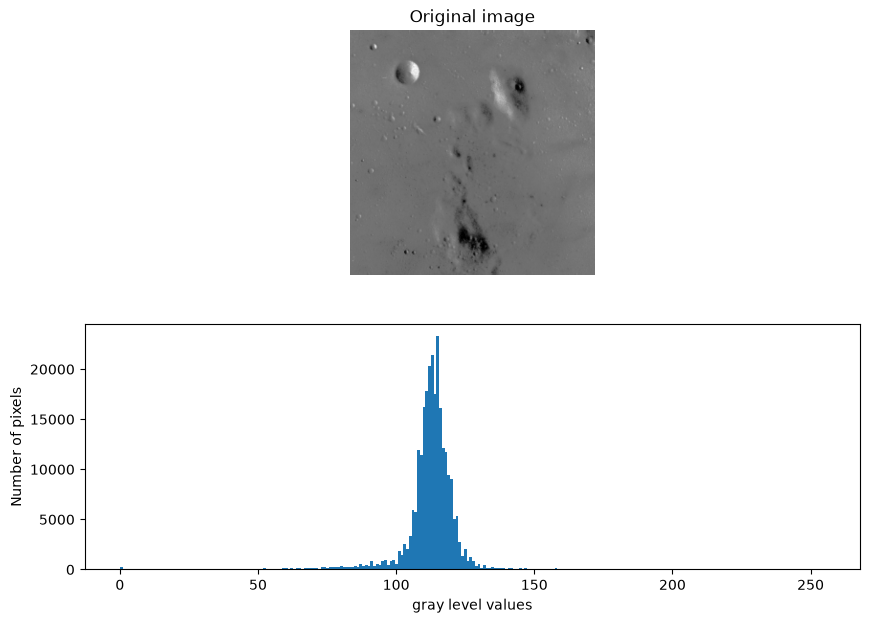

In [4]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

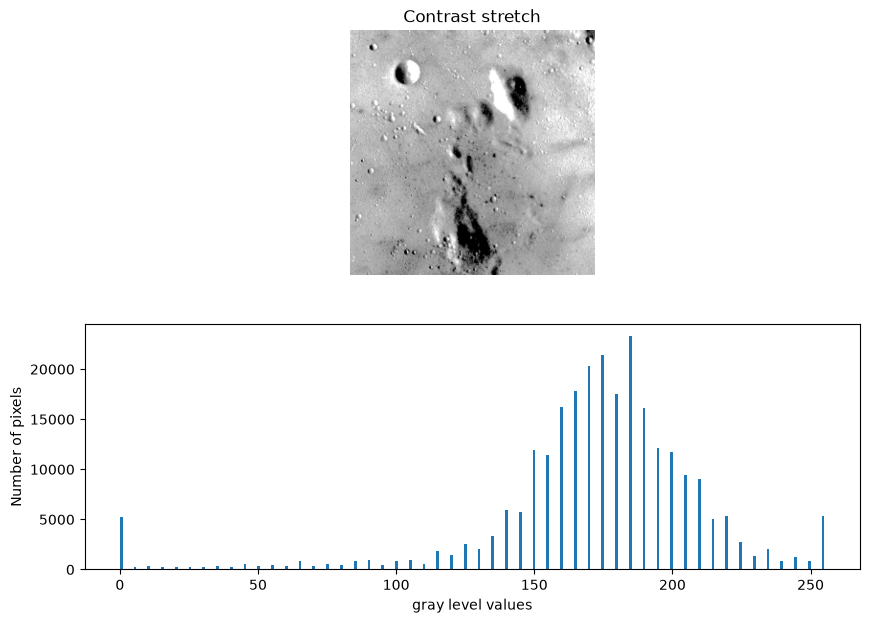

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observations:** the original moon image's histogram is bunched into a narrow band of gray levels, so the picture looks low-contrast. After rescaling, that same band is stretched across the full `0-255` range, so the histogram spreads out and the picture shows noticeably more contrast between its darker and brighter regions.

---
---

# Assessment

### Task #1 — Rescale to the 3rd and 80th percentiles

Same idea as Task #2's contrast stretching above, but with a wider percentile range (3rd-80th instead of 2nd-98th), which clips more of the brightest pixels.

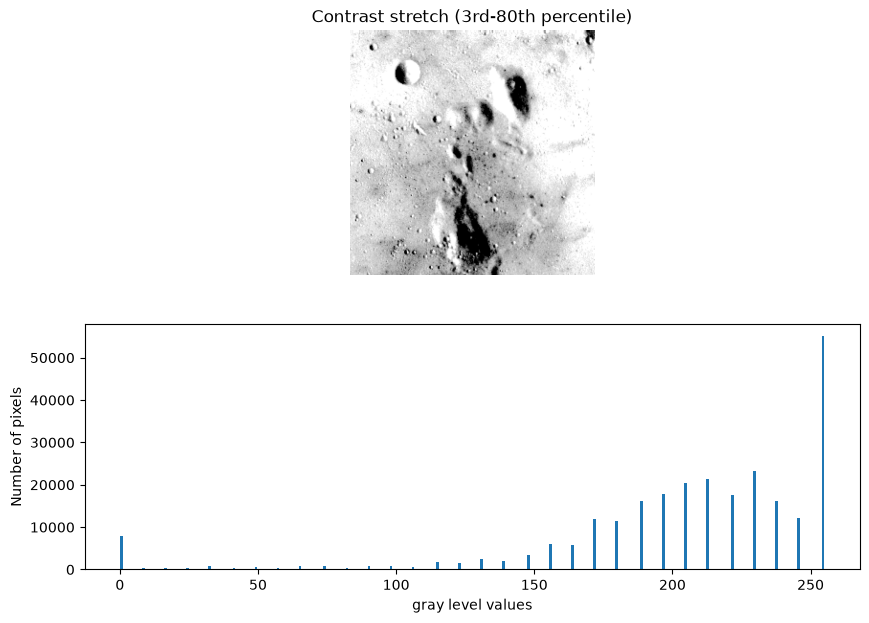

In [6]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task #2 — Equalize the histogram

`exposure.equalize_hist` redistributes gray levels so the histogram becomes approximately flat ("histogram equalization"), which tends to reveal detail across the whole intensity range rather than just the originally dominant band. It returns float values in `[0, 1]`, so the histogram below is plotted on that scale.

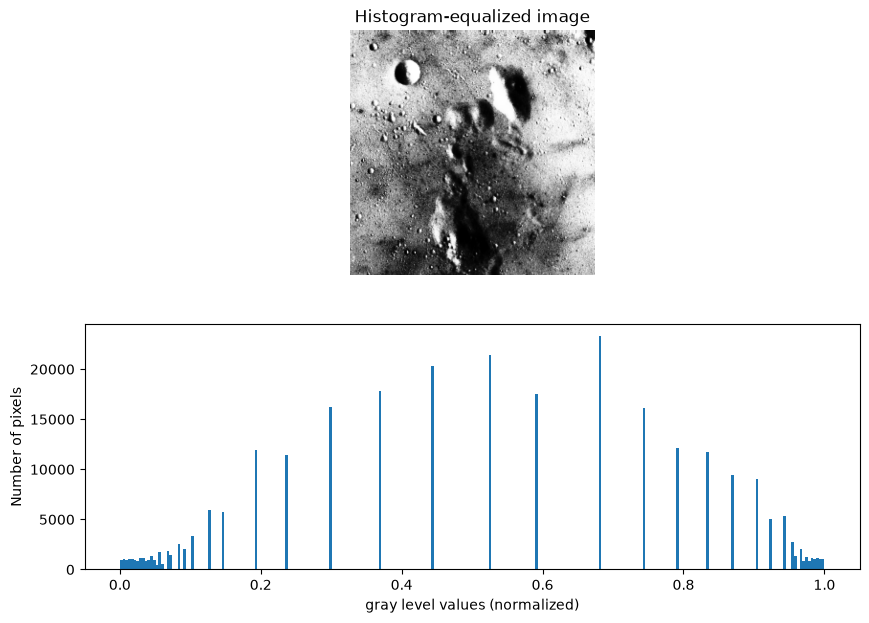

In [7]:
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram-equalized image')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values (normalized)')
plt.ylabel('Number of pixels')
plt.show()

### Task #3 — Histogram matching

`exposure.match_histograms` adjusts the Chelsea image so its histogram matches the Rocket image's (used here as the reference), per color channel. Both images come from `skimage.data`, so no files are needed.

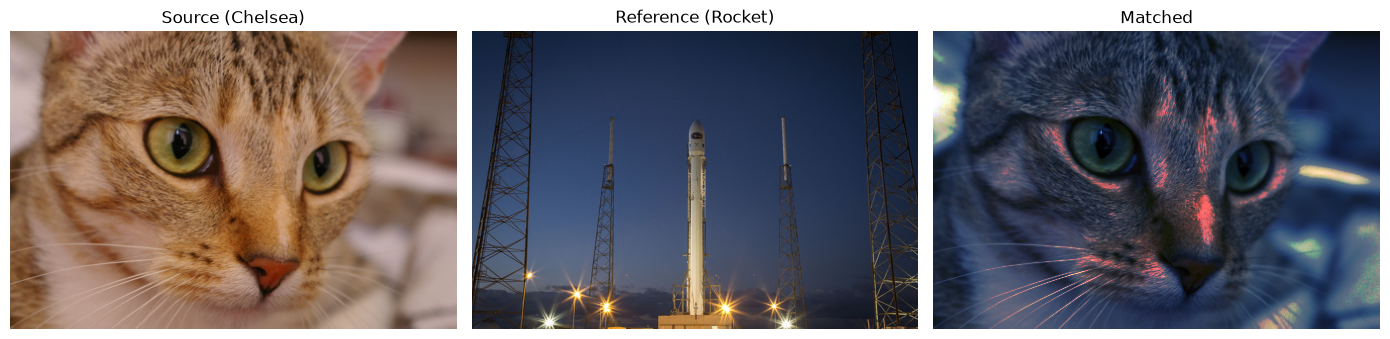

In [8]:
from skimage.exposure import match_histograms

reference = data.rocket()
source = data.chelsea()

matched = match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(source)
axes[0].set_title('Source (Chelsea)')
axes[0].axis('off')
axes[1].imshow(reference)
axes[1].set_title('Reference (Rocket)')
axes[1].axis('off')
axes[2].imshow(matched)
axes[2].set_title('Matched')
axes[2].axis('off')
plt.tight_layout()
plt.show()

**Observations:** the matched image keeps Chelsea's content but its color distribution is pulled toward Rocket's — areas that were brighter or darker than the reference's typical tone shift toward it, so the overall palette (not the shapes) ends up closer to the reference image.

---
## Conclusion

This lab covered two ways to work with pixel intensities: **thresholding**, which collapses an image into a binary foreground/background map, and **histogram processing** (contrast stretching, equalization, and matching), which reshapes an image's distribution of gray levels to improve contrast or match another image's tone.

---




**End of notebook.**